# 03 · Event-driven backtest of an OFI threshold strategy

`OfiStrategy` (C++): rolling OFI over `window_events`, z-scored over `zscore_window`;
enter when |z| > `entry_z` (passive = join the touch, aggressive = cross); exit with a
market order when the signal fades below `exit_z` or after `max_hold`. Fills come from
the queue-position model; every action is delayed by latency.

In [1]:
import sys, time
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "python"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
import lob
from lob import data as D
from lob.reconstruct import replay_day
RESULTS = ROOT / "results"; RESULTS.mkdir(exist_ok=True)
print("lob", lob.__version__, "| tickers:", [d.ticker for d in D.find_days()])

lob 0.1.0 | tickers: ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT']


In [2]:
from lob.backtest import RunSpec, run, sweep, latency_sweep, markouts, PyOfiStrategy
cols = ["ticker","label","latency_us","total_pnl","fees","n_orders","n_fills","fill_rate","volume","pnl_per_share","max_drawdown","forced_close","runtime_s"]
base = run(RunSpec("AMZN"))
pd.Series(base.row())

ticker                     AMZN
label                   passive
latency_us                500.0
entry_z                     2.0
cancel                  ProRata
total_pnl              -226.236
realized_pnl            -221.74
fees                      4.496
max_drawdown            226.236
sharpe               -82.975866
volume                   7992.0
n_fills                     162
n_orders                   1047
n_passive_fills              79
n_aggressive_fills           83
fill_rate              0.117479
pnl_per_share         -0.028308
forced_close              False
runtime_s                 0.041
dtype: object

mean AMZN spread: 13.1 ticks


,vs_mid_ticks,markout_0.1s,markout_1s,markout_5s,markout_30s,n_fills
kind,,,,,,
aggressive (exits),-6.241,1.518,3.006,4.277,3.898,83
passive (entries),1.810,-1.019,-2.297,-3.519,-6.576,79


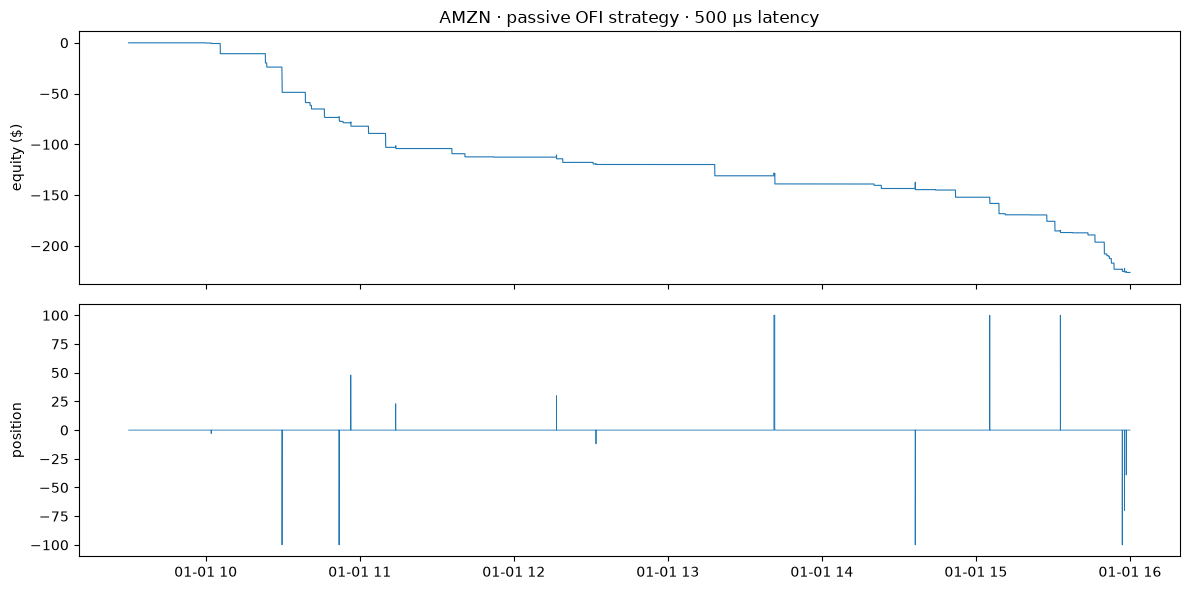

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(base.equity.time, base.equity.equity, lw=.8); ax[0].set_ylabel("equity ($)"); ax[0].set_title("AMZN · passive OFI strategy · 500 µs latency")
ax[1].step(base.equity.time, base.equity.position, lw=.6); ax[1].set_ylabel("position")
fig.tight_layout(); fig.savefig(RESULTS/"amzn_equity.png", dpi=110)
feat, _ = replay_day("AMZN")
print("mean AMZN spread:", round(float(feat.spread_ticks.mean()), 1), "ticks")
markouts(base, feat)

**Mark-outs** read like this: passive entries buy ~2 ticks inside the 13-tick spread
but the mid then moves *against* them (negative mark-outs growing with horizon): we get
filled precisely when someone informed is sweeping our side. Exits pay half the spread
(~6 ticks vs mid) and the mid keeps going the way we were fleeing from. Net: about
−6 ticks per round trip before fees, which the fee schedule barely changes.

## Latency
Passive entries barely depend on latency (we join the back of the queue either way).
Aggressive entries do: with zero latency you react to a print and hit liquidity that was
there *at the same nanosecond*, which nobody can do live. Because this strategy loses,
lower latency simply buys more fills of a bad signal, so PnL *improves* as latency grows;
the point is the dependence, not its sign. A profitable aggressive signal would show the
mirror image, which is exactly the look-ahead inflation a zero-latency backtest hides.

In [4]:
lat = (0, 50, 500, 5000, 50000)
p = latency_sweep("AMZN", lat, passive_entry=True)[cols]; p["mode"] = "passive"
a = latency_sweep("AMZN", lat, passive_entry=False, entry_z=2.5)[cols]; a["mode"] = "aggressive"
both = pd.concat([p, a]); both

,ticker,label,latency_us,total_pnl,fees,n_orders,n_fills,fill_rate,volume,pnl_per_share,max_drawdown,forced_close,runtime_s,mode
0,AMZN,lat0us,0,-247.817,4.257,1051,166,0.120837,8514.0,-0.029107,247.817,False,0.041,passive
1,AMZN,lat50us,50,-254.435,4.305,1052,169,0.122624,8610.0,-0.029551,254.435,False,0.040,passive
2,AMZN,lat500us,500,-226.236,4.496,1047,162,0.117479,7992.0,-0.028308,226.236,False,0.040,passive
3,AMZN,lat5000us,5000,-202.532,4.082,1037,147,0.107040,7604.0,-0.026635,202.532,False,0.040,passive
4,AMZN,lat50000us,50000,-278.455,4.175,1038,158,0.109827,7790.0,-0.035745,278.455,False,0.040,passive
0,AMZN,lat0us,0,-4315.234,214.164,996,1194,0.979920,71388.0,-0.060448,4316.890,False,0.040,aggressive
1,AMZN,lat50us,50,-4261.220,213.150,997,1187,0.978937,71050.0,-0.059975,4262.876,False,0.038,aggressive
2,AMZN,lat500us,500,-4190.654,206.064,982,1118,0.936864,68688.0,-0.061010,4192.310,False,0.039,aggressive
3,AMZN,lat5000us,5000,-4017.714,189.774,944,1016,0.881356,63258.0,-0.063513,4019.370,False,0.041,aggressive
4,AMZN,lat50000us,50000,-3900.874,175.644,928,911,0.808190,58548.0,-0.066627,3902.530,False,0.041,aggressive


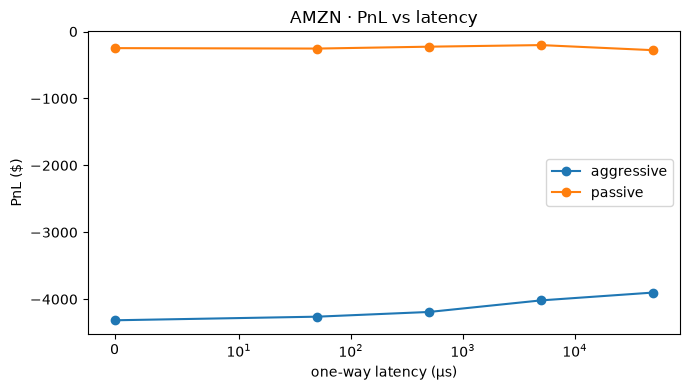

In [5]:
fig, ax = plt.subplots(figsize=(7,4))
for m, g in both.groupby("mode"): ax.plot(g.latency_us, g.total_pnl, marker="o", label=m)
ax.set_xscale("symlog", linthresh=10); ax.set_xlabel("one-way latency (µs)"); ax.set_ylabel("PnL ($)"); ax.legend(); ax.set_title("AMZN · PnL vs latency")
fig.tight_layout(); fig.savefig(RESULTS/"amzn_latency.png", dpi=110)

## Queue-position assumption for cancellations ahead of us

In [6]:
sweep([RunSpec("AMZN", cancel_assumption=c, label=c) for c in ("Pessimistic","ProRata","Optimistic")])[cols]

,ticker,label,latency_us,total_pnl,fees,n_orders,n_fills,fill_rate,volume,pnl_per_share,max_drawdown,forced_close,runtime_s
0,AMZN,Pessimistic,500.0,-215.382,4.122,1039,138,0.105871,7244.0,-0.029732,215.382,False,0.042
1,AMZN,ProRata,500.0,-226.236,4.496,1047,162,0.117479,7992.0,-0.028308,226.236,False,0.041
2,AMZN,Optimistic,500.0,-236.846,4.716,1046,152,0.116635,8432.0,-0.028089,236.846,False,0.048


## All tickers, and gross vs net of fees

In [7]:
rows = []
for t in ["AMZN","AAPL","GOOG","INTC","MSFT"]:
    r = run(RunSpec(t, label="net")); rows.append(r.row() | {"gross_pnl": r.metrics["total_pnl"] + r.metrics["fees"]})
pd.DataFrame(rows)[cols + ["gross_pnl"]]

,ticker,label,latency_us,total_pnl,fees,n_orders,n_fills,fill_rate,volume,pnl_per_share,max_drawdown,forced_close,runtime_s,gross_pnl
0,AMZN,net,500.0,-226.236,4.496,1047,162,0.117479,7992.0,-0.028308,226.236,False,0.044,-221.74
1,AAPL,net,500.0,-667.534,11.664,1348,345,0.196588,21228.0,-0.031446,667.534,False,0.066,-655.87
2,GOOG,net,500.0,-290.217,3.087,820,99,0.084146,5174.0,-0.056091,303.317,False,0.025,-287.13
3,INTC,net,500.0,-29.652,4.892,1196,137,0.097826,9784.0,-0.003031,29.652,False,0.071,-24.76
4,MSFT,net,500.0,-41.889,6.209,1292,161,0.109907,12418.0,-0.003373,41.889,False,0.075,-35.68


## Threshold sweep (fewer, stronger signals)

In [8]:
sweep([RunSpec("AMZN", entry_z=z, label=f"z={z}") for z in (2.0, 2.5, 3.0, 4.0)])[cols]

,ticker,label,latency_us,total_pnl,fees,n_orders,n_fills,fill_rate,volume,pnl_per_share,max_drawdown,forced_close,runtime_s
0,AMZN,z=2.0,500.0,-226.236,4.496,1047,162,0.117479,7992.0,-0.028308,226.236,False,0.041
1,AMZN,z=2.5,500.0,-150.535,2.405,612,92,0.119281,4810.0,-0.031296,150.535,False,0.041
2,AMZN,z=3.0,500.0,-82.043,1.543,339,69,0.156342,3086.0,-0.026586,82.043,False,0.041
3,AMZN,z=4.0,500.0,-12.453,0.223,99,15,0.111111,446.0,-0.027922,12.645,False,0.039


## Python strategy through the pybind11 trampoline
Same rules in Python (`PyOfiStrategy`). Fills must match the C++ version exactly; the
runtime difference is the cost of one Python callback per market event.

In [9]:
spec = RunSpec("AMZN")
cpp = run(spec); py = run(spec, strategy=PyOfiStrategy(spec.params()))
same = cpp.fills[["ts","side","price","qty"]].reset_index(drop=True).equals(py.fills[["ts","side","price","qty"]].reset_index(drop=True))
print(f"identical fills: {same} | C++ {cpp.seconds*1e3:.0f} ms vs Python {py.seconds*1e3:.0f} ms ({py.seconds/cpp.seconds:.0f}x), {len(D.load_messages('AMZN')):,} events")

identical fills: True | C++ 44 ms vs Python 558 ms (13x), 269,748 events


## Reading the results
* The signal is real (t-stats of 4 to 21 contemporaneously) but the naive rule loses a few
  cents per share: passive entries get filled mostly when the price is about to move
  against them (mark-out about −2 ticks after 1 s, −6 after 30 s on AMZN), and exits
  pay half of a 13-tick spread.
* Fees are a small part of the loss; adverse selection dominates.
* This is the point of an event-driven backtester with realistic fills: a vectorised
  backtest that fills every limit order at its price would have shown a profit here.